# 03: Body-Language Metrics (Member 3)

Consumes Member 1's `outputs/presenter_keypoints.csv` and produces the
per-second body-language metrics time-series CSV + evidence plots.

Scope: posture stability, gesture frequency, movement dynamics only.
Does not touch pose inference (M1), tracking/heatmaps (M2), training/eval
(M4), or the dashboard/export (M5).

In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
import pandas as pd

from body_language_metrics import generate_metrics, print_validation_report
from body_language_plots import (
    plot_posture_stability,
    plot_gesture_frequency,
    plot_movement_dynamics,
)

## Run the pipeline on Member 1's real keypoints CSV

In [2]:
metrics_df, reports = generate_metrics("../outputs/presenter_keypoints.csv")
print_validation_report(reports)

--- clip1_presenter ---
  fps used:              25.0  (Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322))
  frames:                408  (duration 16.32s)
  posture valid frames:  106 / 408  (26.0%)
  posture invalid:       302
  gesture events:        left=2  right=1
  gestures per minute:   11.03
  movement valid frames: 391 / 408  (excluded 16 as likely presenter-identity-swap outliers)
  mean stability score:  80.62
  mean movement energy:  234.12 px/s

--- clip2_presenter ---
  fps used:              25.0  (Verified: Pexels source file '8244304-uhd_2560_1440_25fps.mp4')
  frames:                212  (duration 8.48s)
  posture valid frames:  95 / 212  (44.8%)
  posture invalid:       117
  gesture events:        left=0  right=1
  gestures per minute:   7.08
  movement valid frames: 193 / 212  (excluded 18 as likely presenter-identity-swap outliers)
  mean stability score:  92.34
  mean movement energy:  175.89 px/s

--- clip3_presenter ---
  fps used:              25.0

## Save the deliverable CSV for Member 5

In [3]:
metrics_df.to_csv("../outputs/body_language_metrics.csv", index=False)
metrics_df.head(15)

,clip,second,posture_angle_deg_mean,posture_sway_std_deg,posture_stability_score,posture_frames_valid,posture_frames_total,gesture_events_left,gesture_events_right,gesture_events_total,gestures_per_minute_clip,movement_energy_px_s,movement_frames_valid,movement_frames_total,fps_used,fps_source
0,clip1_presenter,0,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,188.870185,24,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
1,clip1_presenter,1,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,157.558670,25,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
2,clip1_presenter,2,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,256.670083,25,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
3,clip1_presenter,3,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,194.432718,25,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
4,clip1_presenter,4,27.133318,1.441369,86.576918,16.0,25.0,0,0,0,11.029412,339.311273,22,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
5,clip1_presenter,5,-8.494601,0.700025,93.239151,8.0,25.0,0,0,0,11.029412,219.300860,21,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
6,clip1_presenter,6,-1.963735,4.223763,65.548736,13.0,25.0,0,0,0,11.029412,383.462718,22,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
7,clip1_presenter,7,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,150.598115,25,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
8,clip1_presenter,8,2.743055,NaN,NaN,1.0,25.0,0,0,0,11.029412,237.587322,24,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)
9,clip1_presenter,9,NaN,NaN,NaN,0.0,25.0,0,0,0,11.029412,218.743921,24,25,25.0,Verified: Pexels source file 'uhd_25fps.mp4' (clip id 8244322)


## Evidence plots (reusable helpers, for Member 5's dashboard)

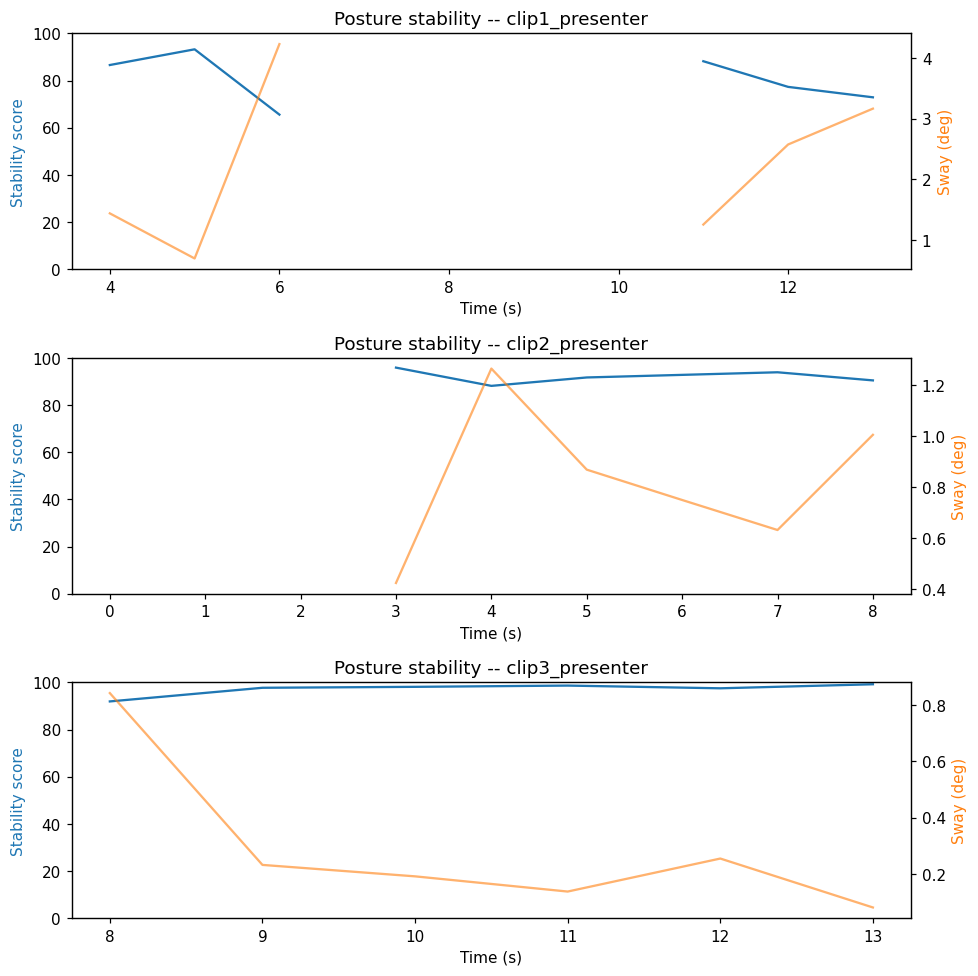

In [4]:
fig = plot_posture_stability(metrics_df)

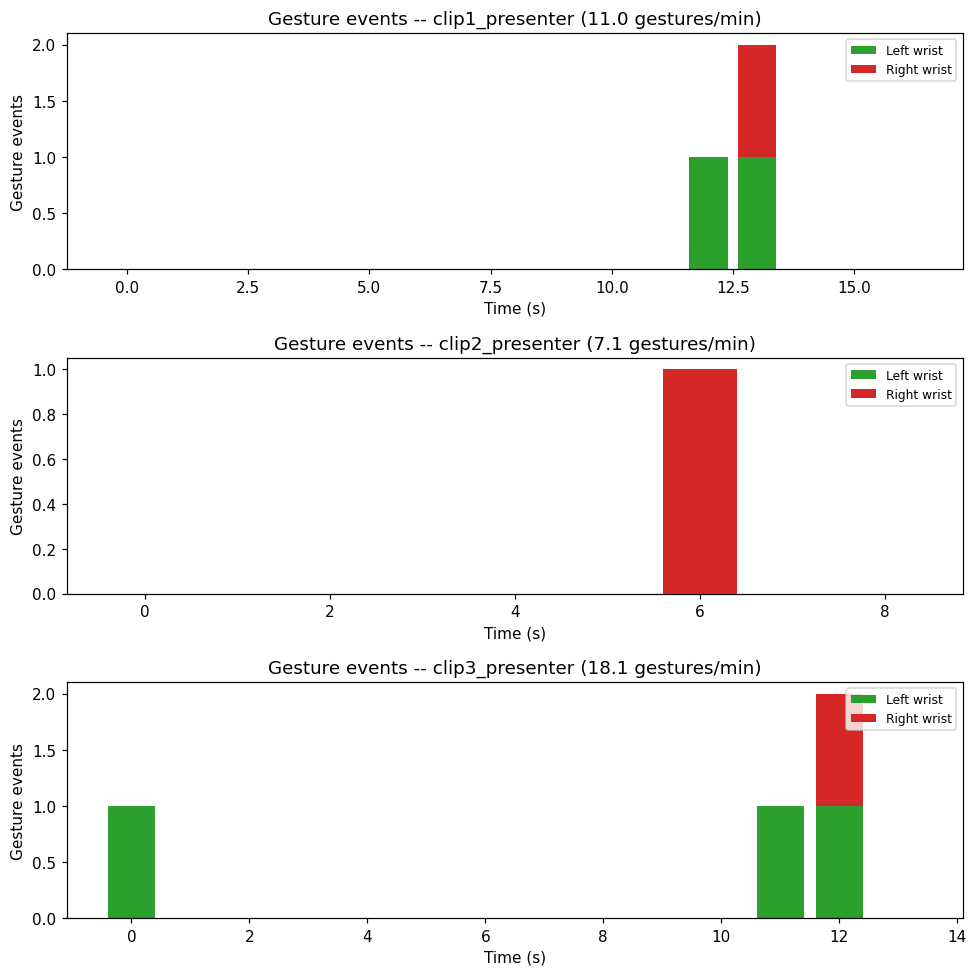

In [5]:
fig = plot_gesture_frequency(metrics_df)

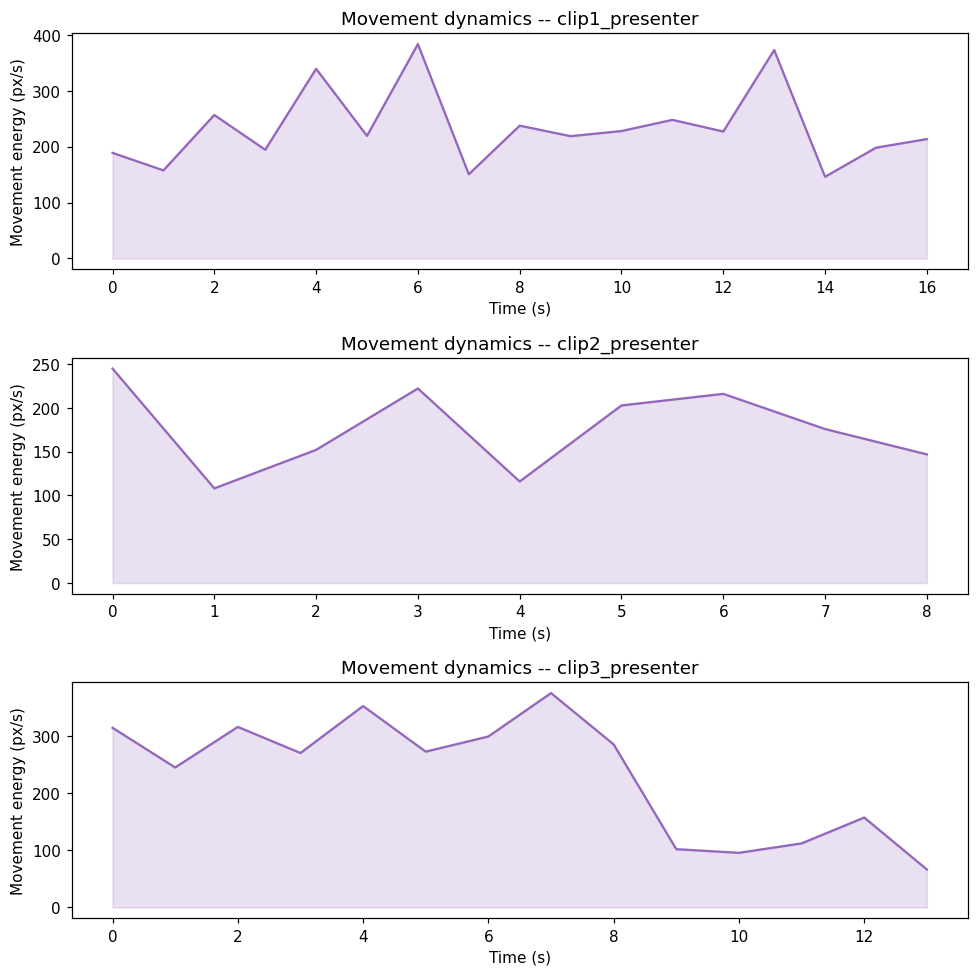

In [6]:
fig = plot_movement_dynamics(metrics_df)